In [1]:
import omics_topic
import muon as mu
import torch
import scanpy as sc
import matplotlib.pyplot as plt

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mdata = mu.read_h5mu("/scratch/fcaretti/GSE158013/GSM5123951.h5mu")
mdata_original = mdata.copy()

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0

In [3]:
mdata.mod["prot"].X = mdata.mod["prot"].layers["counts"]
mdata.mod["rna"].X = mdata.mod["rna"].layers["counts"]
mdata.mod["atac"].X = mdata.mod["atac"].layers["counts"]

In [4]:
sc.pp.normalize_per_cell(mdata["rna"])
sc.pp.log1p(mdata["rna"])
sc.pp.highly_variable_genes(mdata["rna"], n_top_genes=1000, subset=True)
sc.pp.pca(mdata["rna"], n_comps=50, use_highly_variable=False)
sc.pp.neighbors(mdata["rna"], n_neighbors=10)
sc.tl.umap(mdata["rna"])

/tmp/ipykernel_4095660/4005388432.py:1: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(mdata["rna"])
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:591: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(
adata.X seems to be already log-transformed.
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)


In [5]:
mdata_original["rna"].var["highly_variable"] = mdata["rna"].var["highly_variable"]
mdata["rna"].X = mdata["rna"].layers["counts"]

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mod_weights = {"rna": 1, "protein": 20, "chromatin": 1 / 90}

In [7]:
model = omics_topic.models.Gibbs_LDA_Multi(mdata, n_topics=10, device=device, alpha=0.01)

Initializing model with the following modalities: ['rna', 'chromatin', 'protein']


/u/f/fcaretti/omics-topic/src/omics_topic/models/gibbs.py:205: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "gamma": torch.tensor(gamma, device=self.device),
/u/f/fcaretti/omics-topic/src/omics_topic/models/gibbs.py:206: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "tau": torch.tensor(tau, device=self.device),


In [8]:
"""from sklearn.decomposition import NMF

# ---- prepare RNA matrix as dense float ------------------------------
X_rna = model.data_dict['rna'].cpu().float().numpy()   # C × G

# ---- factorise -------------------------------------------------------
nmf = NMF(n_components=model.K,
          max_iter=300)
W = nmf.fit_transform(X_rna)          # C × K
H = nmf.components_                   # K × G

# ---- seed theta & lambda --------------------------------------------
theta0 = torch.tensor(W, device=model.device)
theta0 /= theta0.sum(1, keepdim=True)
model.theta.copy_(theta0)

lambda0 = torch.tensor(H, device=model.device)
model.lambda_['rna'] = lambda0"""

"from sklearn.decomposition import NMF\n\n# ---- prepare RNA matrix as dense float ------------------------------\nX_rna = model.data_dict['rna'].cpu().float().numpy()   # C × G\n\n# ---- factorise -------------------------------------------------------\nnmf = NMF(n_components=model.K,\n          max_iter=300)\nW = nmf.fit_transform(X_rna)          # C × K\nH = nmf.components_                   # K × G\n\n# ---- seed theta & lambda --------------------------------------------\ntheta0 = torch.tensor(W, device=model.device)\ntheta0 /= theta0.sum(1, keepdim=True)\nmodel.theta.copy_(theta0)\n\nlambda0 = torch.tensor(H, device=model.device)\nmodel.lambda_['rna'] = lambda0"

In [9]:
'''def topic_feature_counts(theta: torch.Tensor, X_counts: torch.Tensor) -> torch.Tensor:
    """
    theta      : C × K   (float32, on GPU or CPU)
    X_counts   : C × G   (int64 counts)

    returns    : K × G   expected topic–feature counts
    """
    Xf = X_counts.to(theta.device, dtype=torch.float32)   # cast + move
    return theta.T @ Xf
model.theta.copy_(theta0)                 # -------------- θ₀

# --- RNA / protein ---------------------------------------------------
n_k_g = topic_feature_counts(theta0, model.data_dict['rna'])
gamma0 = model.priors['rna']['gamma']
tau0   = model.priors['rna']['tau']
lambda_rna0 = (gamma0 + n_k_g) / (tau0 + theta0.sum(0).unsqueeze(1))
model.lambda_['rna'] = lambda_rna0

n_k_p = topic_feature_counts(theta0, model.data_dict['protein'])
beta0 = model.priors['protein']['beta']            # length P
phi_prot = (beta0.unsqueeze(0) + n_k_p)
phi_prot /= phi_prot.sum(1, keepdim=True)
model.lambda_['protein'] = phi_prot

# --- Chromatin -------------------------------------------------------
n_k_p = topic_feature_counts(theta0, model.data_dict['chromatin'])
beta0 = model.priors['chromatin']['beta']            # length P
phi_chrom = (beta0.unsqueeze(0) + n_k_p)
phi_chrom /= phi_chrom.sum(1, keepdim=True)
model.lambda_['chromatin'] = phi_chrom'''

'def topic_feature_counts(theta: torch.Tensor, X_counts: torch.Tensor) -> torch.Tensor:\n    """\n    theta      : C × K   (float32, on GPU or CPU)\n    X_counts   : C × G   (int64 counts)\n\n    returns    : K × G   expected topic–feature counts\n    """\n    Xf = X_counts.to(theta.device, dtype=torch.float32)   # cast + move\n    return theta.T @ Xf\nmodel.theta.copy_(theta0)                 # -------------- θ₀\n\n# --- RNA / protein ---------------------------------------------------\nn_k_g = topic_feature_counts(theta0, model.data_dict[\'rna\'])\ngamma0 = model.priors[\'rna\'][\'gamma\']\ntau0   = model.priors[\'rna\'][\'tau\']\nlambda_rna0 = (gamma0 + n_k_g) / (tau0 + theta0.sum(0).unsqueeze(1))\nmodel.lambda_[\'rna\'] = lambda_rna0\n\nn_k_p = topic_feature_counts(theta0, model.data_dict[\'protein\'])\nbeta0 = model.priors[\'protein\'][\'beta\']            # length P\nphi_prot = (beta0.unsqueeze(0) + n_k_p)\nphi_prot /= phi_prot.sum(1, keepdim=True)\nmodel.lambda_[\'protein\'] = p

In [10]:
model.fit(n_samples=100, thin=10, initial_burnin=0, burnin=100)

Gibbs:   0%|          | 0/1100 [00:00<?, ?it/s]

Gibbs: 100%|██████████| 1100/1100 [04:22<00:00,  4.19it/s, ll=-6.24e+08]


In [11]:
theta = model.get_cell_topic_dist()
rna_phi = model.get_feature_topic_dist("rna")
rna_protein = model.get_feature_topic_dist("protein")

In [12]:
diff = (
    model._log_likelihood(include_const=True).cpu().numpy() - model._log_likelihood(include_const=False).cpu().numpy()
)

In [13]:
print(model._log_likelihood(include_const=True).cpu().numpy())

-128719940.0


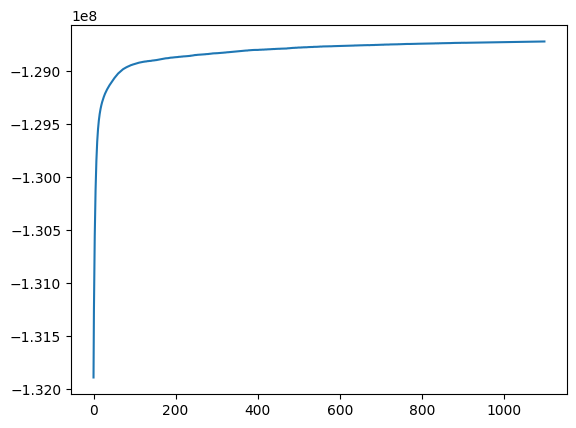

In [14]:
plt.plot(model.ll_history + diff)

In [15]:
model.priors

{'rna': {'gamma': tensor(0.0294, device='cuda:0'),
  'tau': tensor(0.2093, device='cuda:0')},
 'chromatin': {'beta': tensor([0.0010, 0.0010, 0.0010,  ..., 0.0010, 0.0010, 0.0010], device='cuda:0')},
 'protein': {'beta': tensor([0.0027, 0.0018, 0.0334, 0.0117, 0.0046, 0.0126, 0.0043, 0.0253, 0.0130,
          0.0029, 0.0428, 0.0056, 0.0101, 0.0174, 0.0173, 0.0026, 0.0033, 0.0502,
          0.0029, 0.0062, 0.1848, 0.0014, 0.0036, 0.0686, 0.0062, 0.1053, 0.0080,
          0.0873, 0.0259, 0.0079, 0.0013, 0.0091, 0.0025, 0.0046, 0.0564, 0.0115,
          0.0028, 0.0555, 0.0131, 0.0016, 0.0087, 0.0388, 0.0023, 0.0015, 0.0181,
          0.0482], device='cuda:0')}}

Text(0.5, 58.7222222222222, 'Genes')

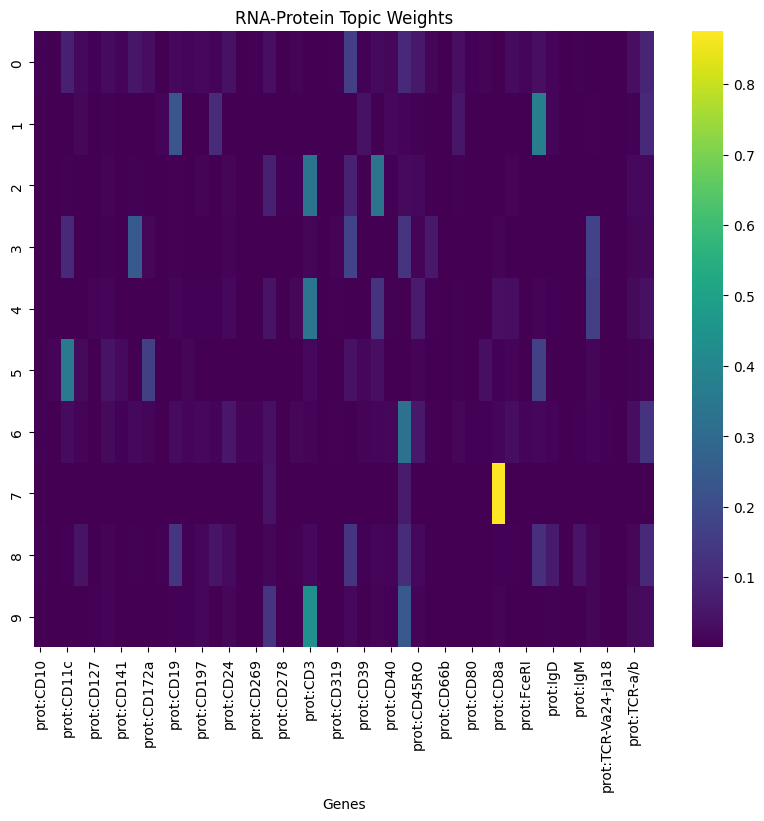

In [16]:
# heatmap of rna protein
import seaborn as sns
import pandas as pd

protein_df = pd.DataFrame(rna_protein.T, index=mdata["prot"].var_names)
protein_df = protein_df.T
plt.figure(figsize=(10, 8))
# ns.heatmap(protein_df, cmap="viridis", annot=True, fmt=".2f", cbar_kws={'label': 'Weight'})
sns.heatmap(protein_df, cmap="viridis", annot=False)
plt.title("RNA-Protein Topic Weights")
plt.xlabel("Genes")

In [17]:
model.theta_samples[0]

tensor([[4.9425e-02, 1.1755e-38, 6.4021e-01,  ..., 1.6641e-02, 2.6705e-22,
         2.0785e-01],
        [1.1755e-38, 1.1755e-38, 3.9337e-01,  ..., 5.8169e-02, 7.0291e-03,
         4.2165e-01],
        [1.3998e-02, 7.3231e-03, 2.8648e-01,  ..., 1.8403e-01, 6.9984e-03,
         4.1929e-01],
        ...,
        [1.7549e-24, 2.5643e-11, 1.1755e-38,  ..., 9.6546e-03, 4.5278e-03,
         1.4967e-01],
        [1.6889e-02, 8.7189e-03, 4.1750e-01,  ..., 1.1755e-38, 1.9285e-03,
         4.1096e-01],
        [1.2973e-02, 4.0000e-03, 5.0509e-01,  ..., 3.9923e-02, 6.7933e-27,
         3.9505e-01]])